In [1]:
%pip install opencv-python
import os
import cv2
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: C:\Users\reddy\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


In [2]:
%matplotlib inline

sns.set_style("whitegrid")

In [3]:
dataset_path = "seg_train/seg_train"

In [4]:
IMAGE_SIZE = 64


In [5]:
classes = sorted(os.listdir(dataset_path))

print("="*70)
print("Classes")
print("="*70)

print(classes)

Classes
['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [6]:
images = []

labels = []

for label in classes:

    folder = os.path.join(dataset_path, label)

    for file in os.listdir(folder):

        image_path = os.path.join(folder, file)

        image = cv2.imread(image_path)

        if image is None:

            continue

        # Convert BGR to RGB

        image = cv2.cvtColor(

            image,

            cv2.COLOR_BGR2RGB

        )

        # Resize image

        image = cv2.resize(

            image,

            (IMAGE_SIZE, IMAGE_SIZE)

        )

        images.append(image)

        labels.append(label)

print("\n")

print("="*70)
print("Images Loaded Successfully")
print("="*70)

print("Total Images :", len(images))



Images Loaded Successfully
Total Images : 14034


In [7]:
images = np.array(images)

labels = np.array(labels)

print("\n")

print("="*70)
print("Image Shape")
print("="*70)

print(images.shape)

print(labels.shape)



Image Shape
(14034, 64, 64, 3)
(14034,)


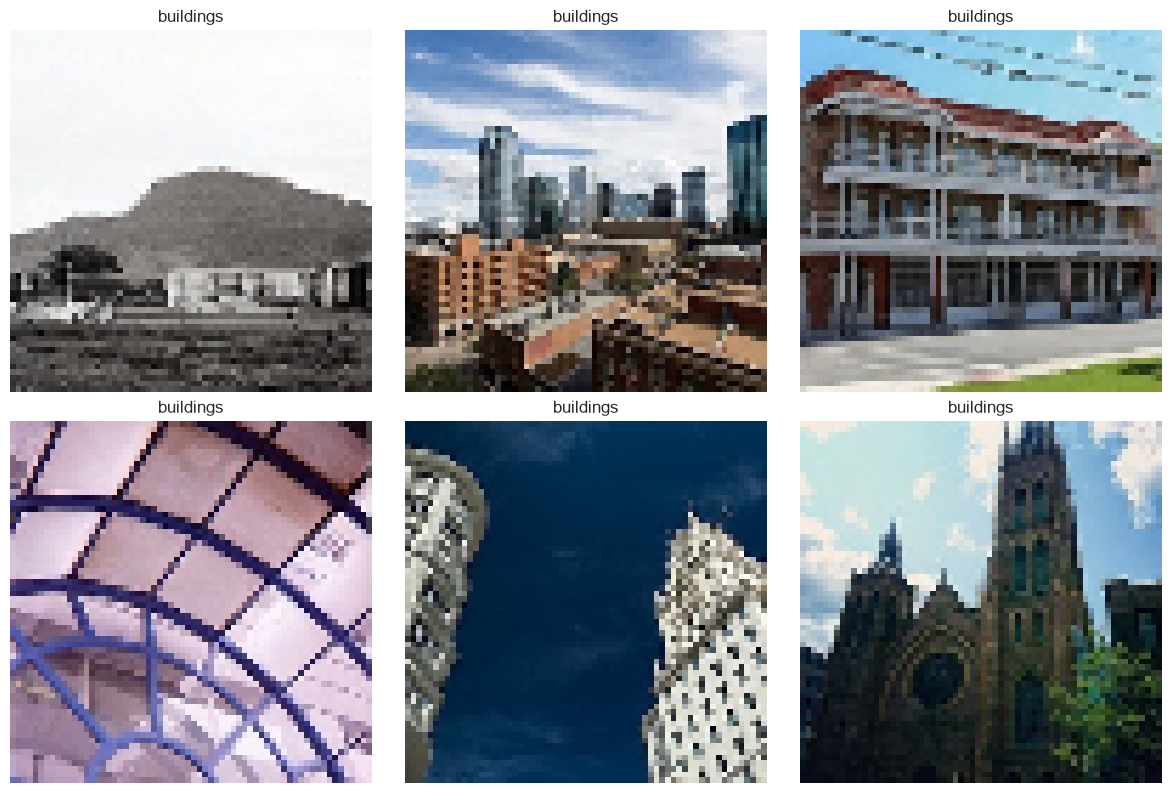

In [8]:
plt.figure(figsize=(12,8))

for i in range(6):

    plt.subplot(2,3,i+1)

    plt.imshow(images[i])

    plt.title(labels[i])

    plt.axis("off")

plt.tight_layout()

plt.show()



Class Distribution
mountain     2512
glacier      2404
street       2382
sea          2274
forest       2271
buildings    2191
Name: count, dtype: int64


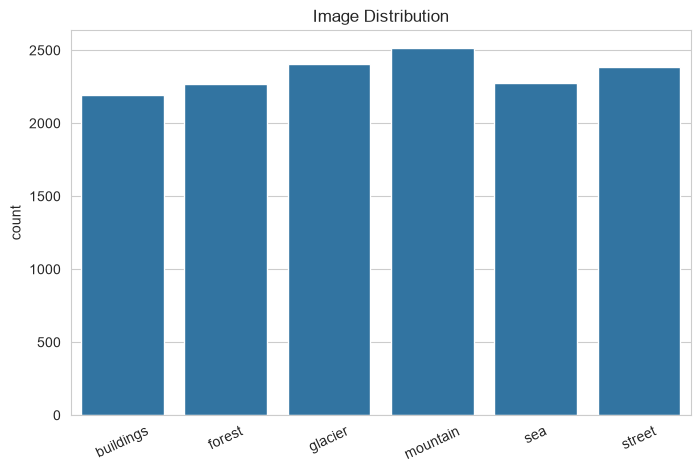

In [9]:
class_counts = pd.Series(labels).value_counts()

print("\n")

print("="*70)
print("Class Distribution")
print("="*70)

print(class_counts)

plt.figure(figsize=(8,5))

sns.countplot(

    x=labels

)

plt.xticks(rotation=25)

plt.title("Image Distribution")

plt.show()

In [10]:
print("\n")

print("="*70)
print("Missing Images")
print("="*70)

print(np.sum(images == None))




Missing Images
0


In [11]:
images = images.astype("float32") / 255.0

print("\n")

print("="*70)
print("Pixel Value Range")
print("="*70)

print("Minimum :", images.min())

print("Maximum :", images.max())




Pixel Value Range
Minimum : 0.0
Maximum : 1.0


In [12]:
X = images.reshape(

    len(images),

    -1

)

print("\n")

print("="*70)
print("Flattened Shape")
print("="*70)

print(X.shape)



Flattened Shape
(14034, 12288)


In [13]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y = encoder.fit_transform(labels)

print("\n")

print("="*70)
print("Encoded Classes")
print("="*70)

for i, name in enumerate(encoder.classes_):

    print(i, "->", name)



Encoded Classes
0 -> buildings
1 -> forest
2 -> glacier
3 -> mountain
4 -> sea
5 -> street


In [14]:
print("\n")

print("="*70)
print("Final Dataset")
print("="*70)

print("Input Shape :", X.shape)

print("Target Shape:", y.shape)




Final Dataset
Input Shape : (14034, 12288)
Target Shape: (14034,)


In [15]:
from sklearn.model_selection import train_test_split

# Use only 3000 images

X_small, _, y_small, _ = train_test_split(

    X,

    y,

    train_size=3000,

    stratify=y,

    random_state=42

)

print("="*70)
print("Reduced Dataset")
print("="*70)

print(X_small.shape)
print(y_small.shape)

Reduced Dataset
(3000, 12288)
(3000,)


In [16]:
X_train, X_test, y_train, y_test = train_test_split(

    X_small,

    y_small,

    test_size=0.20,

    random_state=42,

    stratify=y_small

)

print("\n")

print("="*70)
print("Training Dataset")
print("="*70)

print("X_train :", X_train.shape)
print("y_train :", y_train.shape)

print("\n")

print("="*70)
print("Testing Dataset")
print("="*70)

print("X_test :", X_test.shape)
print("y_test :", y_test.shape)




Training Dataset
X_train : (2400, 12288)
y_train : (2400,)


Testing Dataset
X_test : (600, 12288)
y_test : (600,)


In [17]:

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

print("\nFeature Scaling Completed!")


Feature Scaling Completed!


In [18]:
from sklearn.svm import SVC

svm_model = SVC(

    kernel="linear",

    C=1,

    random_state=42

)

svm_model.fit(

    X_train,

    y_train

)

print("\n")

print("="*70)
print("SVM Model Trained Successfully")
print("="*70)




SVM Model Trained Successfully


In [19]:
y_pred = svm_model.predict(

    X_test

)

In [20]:
from sklearn.metrics import (

    accuracy_score,

    precision_score,

    recall_score,

    f1_score

)

accuracy = accuracy_score(

    y_test,

    y_pred

)

precision = precision_score(

    y_test,

    y_pred,

    average="weighted"

)

recall = recall_score(

    y_test,

    y_pred,

    average="weighted"

)

f1 = f1_score(

    y_test,

    y_pred,

    average="weighted"

)

print("\n")

print("="*70)
print("Model Performance")
print("="*70)

print(f"Accuracy  : {accuracy:.4f}")

print(f"Precision : {precision:.4f}")

print(f"Recall    : {recall:.4f}")

print(f"F1 Score  : {f1:.4f}")




Model Performance
Accuracy  : 0.4950
Precision : 0.5061
Recall    : 0.4950
F1 Score  : 0.4933


In [21]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(

    svm_model,

    X_train,

    y_train,

    cv=3,

    scoring="accuracy"

)

print("\n")

print("="*70)
print("Cross Validation")
print("="*70)

print(scores)

print("\nAverage CV Accuracy")

print(scores.mean())




Cross Validation
[0.49    0.49125 0.45625]

Average CV Accuracy
0.4791666666666667


In [22]:

print("\n")

print("="*70)
print("Image Classes")
print("="*70)

for i, label in enumerate(encoder.classes_):

    print(i, "->", label)



Image Classes
0 -> buildings
1 -> forest
2 -> glacier
3 -> mountain
4 -> sea
5 -> street


In [23]:
best_model = svm_model

best_predictions = y_pred

best_accuracy = accuracy

best_precision = precision

best_recall = recall

best_f1 = f1

cv_scores = scores

print("\n")

print("="*70)
print("Best Model Selected")
print("="*70)

print("Kernel :", best_model.kernel)

print("C :", best_model.C)



Best Model Selected
Kernel : linear
C : 1


Confusion Matrix
[[26 11  8 30 11  8]
 [ 6 71  1  1  7 11]
 [ 6  1 56 11 28  1]
 [ 5  3 14 61 23  1]
 [10  6 18 20 38  5]
 [10 13  5 12 17 45]]


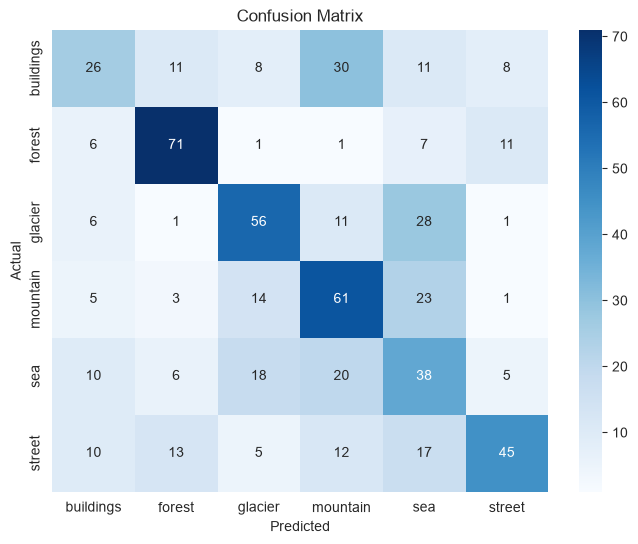

In [24]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(

    y_test,

    best_predictions

)

print("="*70)
print("Confusion Matrix")
print("="*70)

print(cm)

plt.figure(figsize=(8,6))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues",

    xticklabels=encoder.classes_,

    yticklabels=encoder.classes_

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()


In [25]:
from sklearn.metrics import classification_report

print("\n")

print("="*70)
print("Classification Report")
print("="*70)

print(

    classification_report(

        y_test,

        best_predictions,

        target_names=encoder.classes_

    )

)



Classification Report
              precision    recall  f1-score   support

   buildings       0.41      0.28      0.33        94
      forest       0.68      0.73      0.70        97
     glacier       0.55      0.54      0.55       103
    mountain       0.45      0.57      0.50       107
         sea       0.31      0.39      0.34        97
      street       0.63      0.44      0.52       102

    accuracy                           0.49       600
   macro avg       0.51      0.49      0.49       600
weighted avg       0.51      0.49      0.49       600



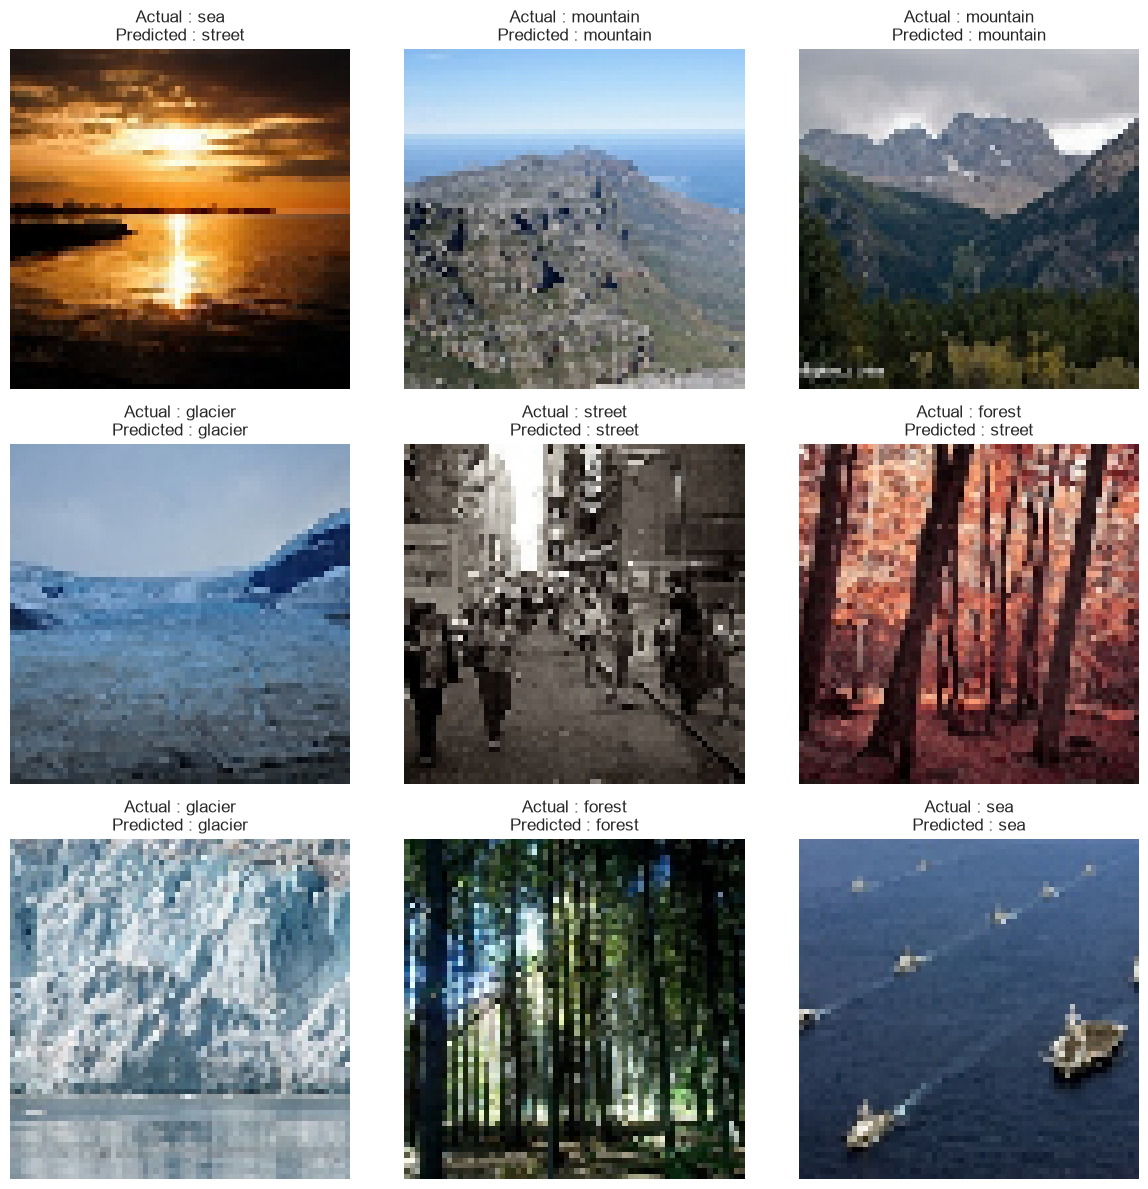

In [26]:
indices = np.random.choice(

    len(X_test),

    9,

    replace=False

)

plt.figure(figsize=(12,12))

for i, idx in enumerate(indices):

    image = scaler.inverse_transform(

        X_test[idx].reshape(1,-1)

    )

    image = image.reshape(

        IMAGE_SIZE,

        IMAGE_SIZE,

        3

    )

    image = np.clip(

        image,

        0,

        1

    )

    actual = encoder.inverse_transform(

        [y_test[idx]]

    )[0]

    predicted = encoder.inverse_transform(

        [best_predictions[idx]]

    )[0]

    plt.subplot(3,3,i+1)

    plt.imshow(image)

    plt.title(

        f"Actual : {actual}\nPredicted : {predicted}"

    )

    plt.axis("off")

plt.tight_layout()

plt.show()


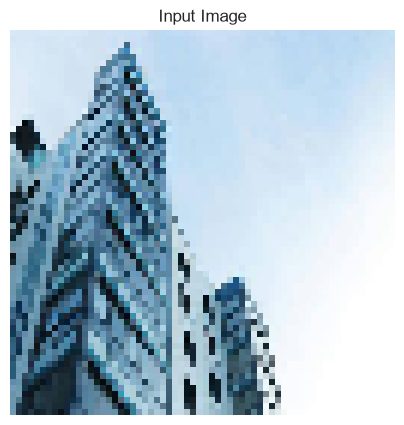

In [27]:

image_path = "sample.jpg"

image = cv2.imread(image_path)

image = cv2.cvtColor(

    image,

    cv2.COLOR_BGR2RGB

)

image = cv2.resize(

    image,

    (IMAGE_SIZE, IMAGE_SIZE)

)

plt.figure(figsize=(5,5))

plt.imshow(image)

plt.title("Input Image")

plt.axis("off")

plt.show()

In [28]:
image = image.astype("float32") / 255.0

In [29]:
image = image.reshape(1,-1)

In [30]:
image = scaler.transform(image)

In [31]:
prediction = best_model.predict(image)

predicted_class = encoder.inverse_transform(prediction)

print("\n")

print("="*70)
print("Prediction")
print("="*70)

print("Predicted Class :", predicted_class[0])



Prediction
Predicted Class : glacier


In [32]:
from joblib import dump

dump(

    best_model,

    "svm_image_classifier.joblib"

)

dump(

    scaler,

    "image_scaler.joblib"

)

dump(

    encoder,

    "label_encoder.joblib"

)

print("\n")

print("="*70)
print("Model Saved Successfully")
print("="*70)




Model Saved Successfully


In [33]:
from joblib import load

loaded_model = load(

    "svm_image_classifier.joblib"

)

loaded_scaler = load(

    "image_scaler.joblib"

)

loaded_encoder = load(

    "label_encoder.joblib"

)

print("\n")

print("="*70)
print("Saved Files Loaded Successfully")
print("="*70)



Saved Files Loaded Successfully


In [34]:
prediction = loaded_model.predict(image)

prediction = loaded_encoder.inverse_transform(

    prediction

)

print("\nPrediction Using Loaded Model")

print(prediction[0])



Prediction Using Loaded Model
glacier


In [35]:
comparison = pd.DataFrame({

    "Actual":

    encoder.inverse_transform(y_test[:10]),

    "Predicted":

    encoder.inverse_transform(best_predictions[:10])

})

print("\n")

print("="*70)
print("Actual vs Predicted")
print("="*70)

print(comparison)



Actual vs Predicted
      Actual  Predicted
0     forest     forest
1        sea   mountain
2  buildings  buildings
3        sea        sea
4        sea    glacier
5     forest     street
6     street    glacier
7     forest     forest
8    glacier        sea
9        sea     street


In [36]:
print("\n")

print("="*70)
print("Image Classification using Support Vector Machine")
print("="*70)

print(f"Training Images : {X_train.shape[0]}")

print(f"Testing Images  : {X_test.shape[0]}")

print(f"Image Size      : {IMAGE_SIZE} x {IMAGE_SIZE}")

print(f"Total Classes   : {len(encoder.classes_)}")

print(f"Kernel Used     : Linear")

print("\n")

print(f"Accuracy        : {best_accuracy:.4f}")

print(f"Precision       : {best_precision:.4f}")

print(f"Recall          : {best_recall:.4f}")

print(f"F1 Score        : {best_f1:.4f}")

print(f"Cross Validation: {cv_scores.mean():.4f}")

print("\n")

print("Model Status : Ready for Deployment")

print("="*70)

print("\nProject Completed Successfully!")





Image Classification using Support Vector Machine
Training Images : 2400
Testing Images  : 600
Image Size      : 64 x 64
Total Classes   : 6
Kernel Used     : Linear


Accuracy        : 0.4950
Precision       : 0.5061
Recall          : 0.4950
F1 Score        : 0.4933
Cross Validation: 0.4792


Model Status : Ready for Deployment

Project Completed Successfully!
